## chicago-taxi-analysis


----

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datasets
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
print(df_companies.info())
print(df_companies.head())

# Revisión general del segundo dataset (Barrios)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [4]:
#La columna de average_trip está en decimal

In [5]:
# Revisión general del segundo dataset (Barrios)
print(df_neighborhoods.info())
print(df_neighborhoods.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [6]:
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


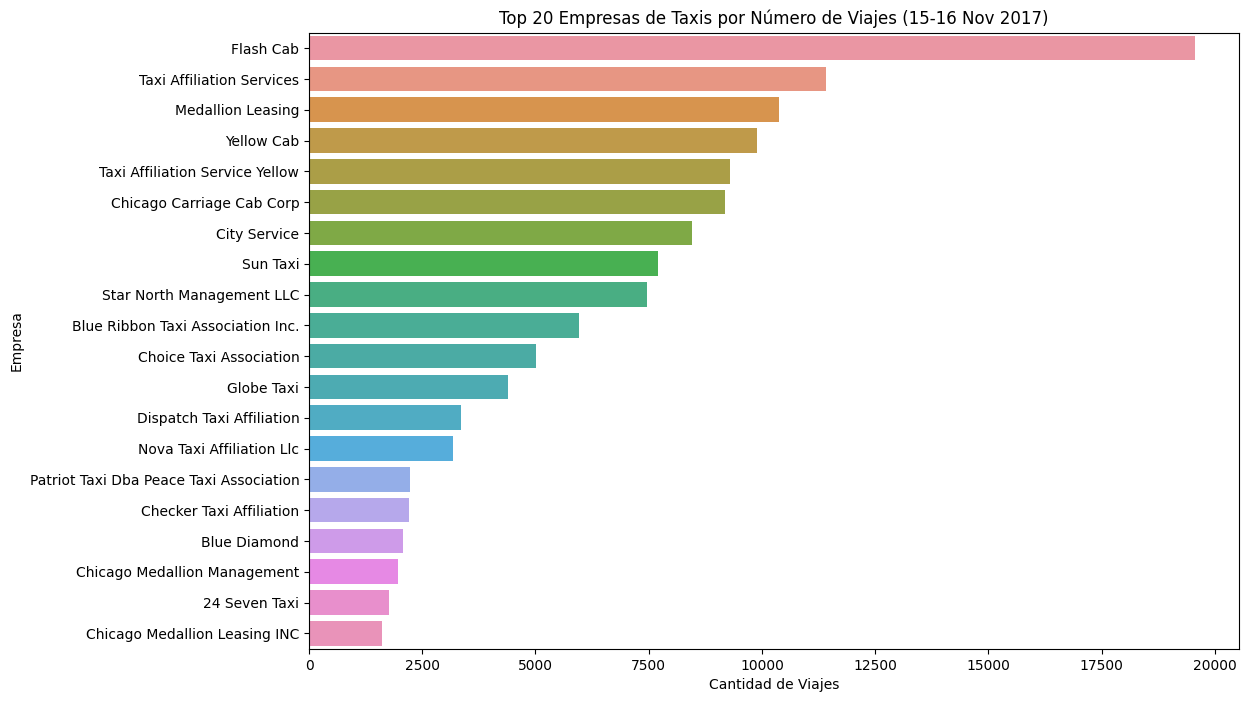

In [7]:
plt.figure(figsize=(12, 8))
sns.barplot(x='trips_amount', y='company_name', data=df_companies.sort_values(by='trips_amount', ascending=False).head(20))
plt.title('Top 20 Empresas de Taxis por Número de Viajes (15-16 Nov 2017)')
plt.xlabel('Cantidad de Viajes')
plt.ylabel('Empresa')
plt.show()

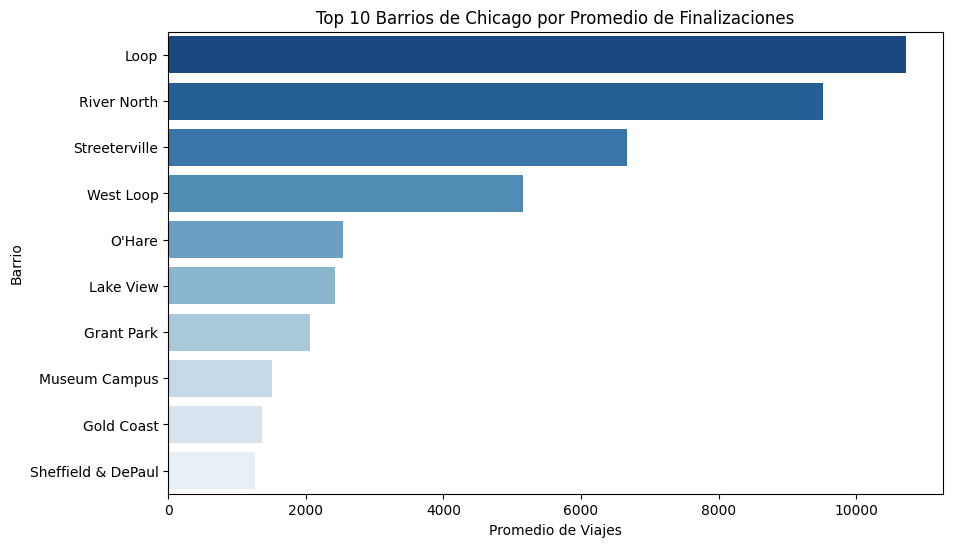

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x='average_trips', y='dropoff_location_name', data=top_10_neighborhoods, palette='Blues_r')
plt.title('Top 10 Barrios de Chicago por Promedio de Finalizaciones')
plt.xlabel('Promedio de Viajes')
plt.ylabel('Barrio')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Buen trabajo obteniendo el top de barrios! El gráfico está ordenado de mayor a menor, lo que permite notar correctamente que Loop Y River North son los principales destinos. Tal vez tienen atractivos importantes que los hacen lugares de muchas visitas.

</div>

In [ ]:
#Conclusiones: Podemos observar que el mayor número de viajes se localiza en el centro de Chicago,sector financiero y comercial. Después continuan zonas turísticas y al final viajes hacia y desde el aeropuerto.
#Dos empresas dominan el mercado de viajes, sin embargo Flash Cab cuenta con una diferencia superiro al resta.
#Como valor agregado y oportunidad para la empresa top y down es revisar la logística de estos viajes para que los usuarios no tarden tanto en tomar su taxi.
#Ya sea que Cab la siga manteniendo o que Chicago Medallion la implemente y gane más presencia en el ercado de taxis.

In [30]:
import pandas as pd
from scipy import stats

# Cargar el dataset
df_trips = pd.read_csv('/datasets/project_sql_result_07.csv')
print(df_companies.info())

# Convertir la columna de tiempo a formato datetime
df_trips['start_ts'] = pd.to_datetime(df_trips['start_ts'])
    

# Eliminar filas con duraciones nulas o cero (que arruinan el promedio)
df_trips = df_trips.dropna(subset=['duration_seconds'])
df_trips = df_trips[df_trips['duration_seconds'] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [39]:

# Filtrar solo los sábados (el sábado es el día 6)
df_saturdays = df_trips[df_trips['start_ts'].dt.dayofweek == 5]

# Crear dos grupos para la prueba

rainy_saturdays = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']
good_saturdays = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']

print(rainy_saturdays)
print(good_saturdays)


6       2969.0
30      1980.0
34      2460.0
51      2760.0
52      2460.0
         ...  
1031    2560.0
1032    1908.0
1053    2400.0
1061    2186.0
1067    2834.0
Name: duration_seconds, Length: 180, dtype: float64
0       2410.0
1       1920.0
2       1543.0
3       2512.0
4       1440.0
         ...  
1060    2700.0
1062    1500.0
1064    1318.0
1065    2100.0
1066    1380.0
Name: duration_seconds, Length: 882, dtype: float64


In [40]:
# Realizar la prueba de hipótesis
alpha = 0.05

results = stats.ttest_ind(rainy_saturdays, good_saturdays, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente de diferencia.")

p-value: 2.4173590471585584e-11
Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración.


In [43]:
#La hipótesis se establece con estos 2 criterios
#Estamos comparando las medias de dos poblaciones distintas (viajes con lluvia vs. viajes sin lluvia).
#La variable dependiente (duración en segundos) es cuantitativa.

#Dado que el valor p es considerablemente menor que el nivel de alfa establecido ($\alpha = 0.05$), contamos con evidencia estadística suficiente para rechazar la hipótesis nula ($H_0$). 
#Por lo tanto, aceptamos la hipótesis alternativa ($H_a$), que sostiene que existe una diferencia significativa en la duración promedio de los viajes desde el Loop hasta el Aeropuerto O'Hare los sábados lluviosos.

In [44]:
print(f"Viajes lluviosos: {len(rainy_saturdays)}")
print(f"Viajes buenos: {len(good_saturdays)}")

Viajes lluviosos: 180
Viajes buenos: 882
